In [1]:
# ==========================================
# CELL 1: IMPORT & PENGGABUNGAN DATA
# ==========================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set style grafik agar elegan untuk skripsi
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# 1. Daftar File (Sesuaikan path jika file berada di dalam folder tertentu, misal 'results/')
PATH = '../data/results/' # Isi './results/' jika file ada di dalam folder results
file_overall = [
    PATH + 'skenario1_overall_nmt_vs_llm.csv',
    PATH + 'skenario2_distilbert_evaluasi_overall.csv',
    PATH + 'skenario2_mmbert-small_evaluasi_overall.csv',
    PATH + 'skenario2_mmbert-base_evaluasi_overall.csv',
    PATH + 'evaluasi_overall_nmt_vs_gemini.csv'
]
file_tipe = [
    PATH + 'skenario1_tipe_kueri_nmt_vs_llm.csv',
    PATH + 'skenario2_distilbert_evaluasi_tipe_kueri.csv',
    PATH + 'skenario2_mmbert-small_evaluasi_tipe_kueri.csv',
    PATH + 'skenario2_mmbert-base_evaluasi_tipe_kueri.csv',
    PATH + 'evaluasi_tipe_kueri_nmt_vs_gemini.csv'
]
file_detail = [
    PATH + 'skenario1_detail_per_kueri_nmt_vs_llm.csv',
    PATH + 'skenario2_distilbert_detail_per_kueri.csv',
    PATH + 'skenario2_mmbert-small_detail_per_kueri.csv',
    PATH + 'skenario2_mmbert-base_detail_per_kueri.csv',
    PATH + 'detail_per_kueri_nmt_vs_gemini.csv'
]

# 2. Fungsi Penggabungan
def gabung_csv(list_file):
    df_list = []
    for file in list_file:
        if os.path.exists(file):
            df = pd.read_csv(file)
            if 'skenario1' in file:
                df.insert(0, 'Skenario', '1. BM25 (Sparse)')
            elif 'skenario2' in file:
                df.insert(0, 'Skenario', '2. Cross-Lingual (Dense)')
            elif 'nmt_vs_gemini' in file:
                df.insert(0, 'Skenario', '3. AraDPR (Monolingual)')
            df_list.append(df)
        else:
            print(f"⚠️ File tidak ditemukan: {file}")
            
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

print("Membaca dan menggabungkan data...")
df_overall = gabung_csv(file_overall)
df_tipe = gabung_csv(file_tipe)
df_detail = gabung_csv(file_detail)

print(f"✅ Data Overall: {len(df_overall)} model")
print(f"✅ Data Per Tipe: {len(df_tipe)} baris")
print(f"✅ Data Detail : {len(df_detail)} baris")

Membaca dan menggabungkan data...
✅ Data Overall: 12 model
✅ Data Per Tipe: 36 baris
✅ Data Detail : 1836 baris


🏆 KLASEMEN MODEL TERBAIK (Diurutkan berdasarkan Hits@10)


,Skenario,name,recip_rank,success_10 (%),success_20 (%)
0,1. BM25 (Sparse),BM25 (Gemini LLM),0.3413,54.25,64.05
1,1. BM25 (Sparse),BM25+RM3 (Gemini LLM),0.3376,52.94,62.09
2,2. Cross-Lingual (Dense),mmBERT-base Fine-Tuned (JH-POLO),0.2605,50.33,58.82
3,2. Cross-Lingual (Dense),mmBERT-small Fine-Tuned (JH-POLO),0.2475,39.22,48.37
4,2. Cross-Lingual (Dense),DistilBERT Base Fine-Tuned (JH-POLO),0.1627,30.72,38.56
5,1. BM25 (Sparse),BM25+RM3 (Google NMT),0.1593,27.45,40.52
6,1. BM25 (Sparse),BM25 (Google NMT),0.1632,26.14,33.99
7,3. AraDPR (Monolingual),AraDPR (Gemini AI),0.0731,15.69,22.22
8,3. AraDPR (Monolingual),AraDPR (Google NMT),0.0438,11.11,15.69
9,2. Cross-Lingual (Dense),Baseline (DistilBERT Base),0.0149,1.96,5.88


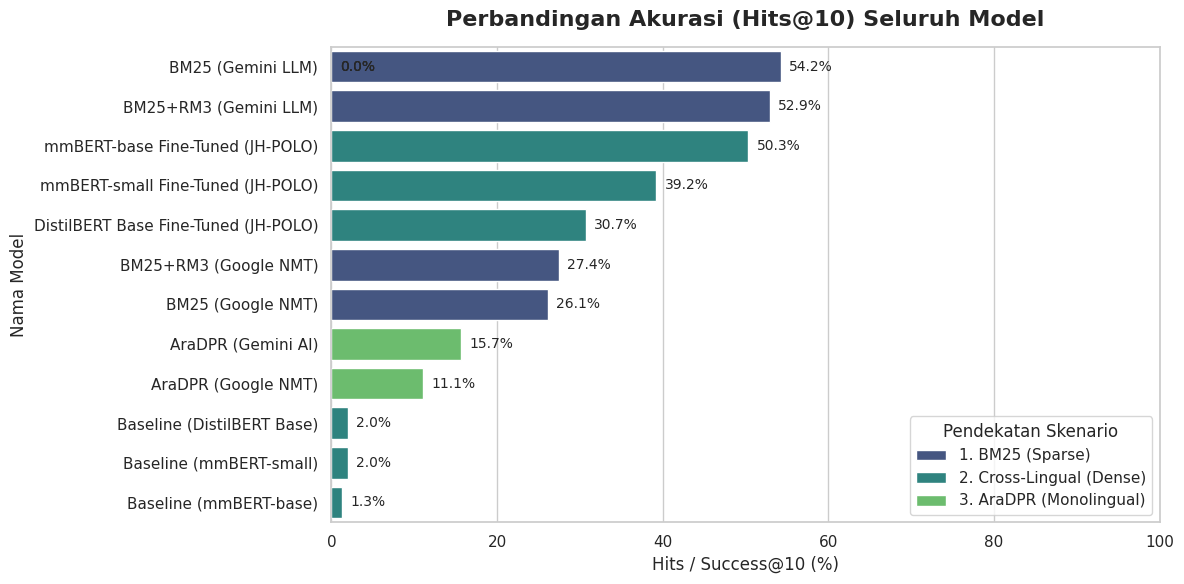

📊 Grafik berhasil disimpan sebagai 'grafik_overall_hits10.png'


In [2]:
# ==========================================
# CELL 2: PERINGKAT KESELURUHAN (OVERALL RANKING)
# ==========================================
print("🏆 KLASEMEN MODEL TERBAIK (Diurutkan berdasarkan Hits@10)")

# Mengurutkan dari nilai terbesar ke terkecil
df_overall_sorted = df_overall.sort_values(by='success_10 (%)', ascending=False).reset_index(drop=True)
display(df_overall_sorted[['Skenario', 'name', 'recip_rank', 'success_10 (%)', 'success_20 (%)']])

# --- MEMBUAT VISUALISASI GRAFIK BAR ---
plt.figure(figsize=(12, 6))

# Kita visualisasikan Success@10 (Hits@10)
ax = sns.barplot(
    data=df_overall_sorted, 
    x='success_10 (%)', 
    y='name', 
    hue='Skenario',
    dodge=False, # Agar bar tidak tumpang tindih
    palette='viridis'
)

plt.title('Perbandingan Akurasi (Hits@10) Seluruh Model', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hits / Success@10 (%)', fontsize=12)
plt.ylabel('Nama Model', fontsize=12)
plt.xlim(0, 100) # Persentase maksimal 100%

# Menambahkan angka di sebelah ujung bar
for p in ax.patches:
    width = p.get_width()
    if pd.isna(width): continue
    plt.text(width + 1, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontsize=10)

plt.legend(title='Pendekatan Skenario', loc='lower right')
plt.tight_layout()
plt.savefig('grafik_overall_hits10.png', dpi=300)
plt.show()
print("📊 Grafik berhasil disimpan sebagai 'grafik_overall_hits10.png'")

📊 MATRIKS HITS@20 BERDASARKAN TIPE KUERI


,Skenario,name,Tipe 1 (Kata Kunci),Tipe 2 (Tanya Awam),Tipe 3 (Studi Kasus)
0,1. BM25 (Sparse),BM25 (Gemini LLM),68.63,56.86,37.25
1,1. BM25 (Sparse),BM25 (Google NMT),35.29,23.53,19.61
2,1. BM25 (Sparse),BM25+RM3 (Gemini LLM),68.63,60.78,29.41
3,1. BM25 (Sparse),BM25+RM3 (Google NMT),39.22,21.57,21.57
4,2. Cross-Lingual (Dense),Baseline (DistilBERT Base),1.96,0.00,3.92
5,2. Cross-Lingual (Dense),Baseline (mmBERT-base),1.96,1.96,0.00
6,2. Cross-Lingual (Dense),Baseline (mmBERT-small),0.00,3.92,1.96
7,2. Cross-Lingual (Dense),DistilBERT Base Fine-Tuned (JH-POLO),33.33,29.41,29.41
8,2. Cross-Lingual (Dense),mmBERT-base Fine-Tuned (JH-POLO),37.25,54.90,58.82
9,2. Cross-Lingual (Dense),mmBERT-small Fine-Tuned (JH-POLO),37.25,45.10,35.29


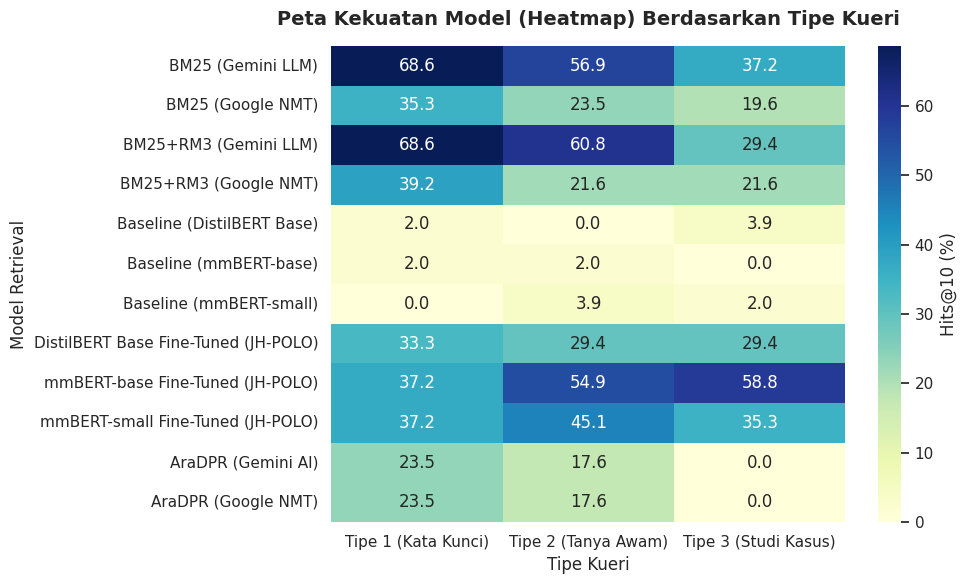

🔥 Heatmap berhasil disimpan sebagai 'grafik_heatmap_tipe_kueri.png'


In [3]:
# ==========================================
# CELL 3: ANALISIS KEKUATAN PER TIPE KUERI
# ==========================================
print("📊 MATRIKS HITS@20 BERDASARKAN TIPE KUERI")

# Membuat tabel pivot agar Tipe Kueri menjadi kolom di atas
pivot_tipe = df_tipe.pivot_table(
    index=['Skenario', 'name'], 
    columns='query_type', 
    values='success_10 (%)'
).reset_index()

# Merapikan nama kolom
pivot_tipe.columns.name = None
pivot_tipe = pivot_tipe.rename(columns={
    1: 'Tipe 1 (Kata Kunci)', 
    2: 'Tipe 2 (Tanya Awam)', 
    3: 'Tipe 3 (Studi Kasus)'
})

# Urutkan berdasarkan performa Skenario
pivot_tipe = pivot_tipe.sort_values(by=['Skenario', 'name'])
display(pivot_tipe)

# --- VISUALISASI HEATMAP (SANGAT ELEGAN UNTUK SKRIPSI) ---
plt.figure(figsize=(10, 6))
# Ambil data angkanya saja untuk heatmap
heatmap_data = pivot_tipe.set_index('name')[['Tipe 1 (Kata Kunci)', 'Tipe 2 (Tanya Awam)', 'Tipe 3 (Studi Kasus)']]

sns.heatmap(
    heatmap_data, 
    annot=True,      # Tampilkan angka
    fmt=".1f",       # 1 angka di belakang koma
    cmap="YlGnBu",   # Skala warna Biru-Hijau
    cbar_kws={'label': 'Hits@10 (%)'}
)

plt.title('Peta Kekuatan Model (Heatmap) Berdasarkan Tipe Kueri', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Model Retrieval')
plt.xlabel('Tipe Kueri')
plt.tight_layout()
plt.savefig('grafik_heatmap_tipe_kueri.png', dpi=300)
plt.show()
print("🔥 Heatmap berhasil disimpan sebagai 'grafik_heatmap_tipe_kueri.png'")

In [4]:
# ==========================================
# CELL 4: AUTOMATIC CASE STUDY FINDER
# ==========================================
print("🔍 MENCARI BUKTI KASUS UNTUK BAB 4")

# Kita pivot df_detail agar setiap model memiliki kolom 'Hit@20'-nya sendiri
detail_pivot = df_detail.pivot_table(
    index=['qid', 'query_type', 'query'],
    columns='name',
    values='Hit@20',
    aggfunc='first'
).reset_index()

# ------------- KASUS 1: EFEK FINE-TUNING (JH-POLO) -------------
# Mencari kueri di mana mmBERT-Base gagal, tapi setelah Fine-Tuned (JH-POLO) dia berhasil
if 'Baseline (mmBERT Base)' in detail_pivot.columns and 'Fine-Tuned mmBERT-Base (JH-POLO)' in detail_pivot.columns:
    kasus_finetuning = detail_pivot[
        (detail_pivot['Baseline (mmBERT Base)'] == '❌ Miss') & 
        (detail_pivot['Fine-Tuned mmBERT-Base (JH-POLO)'] == '✅ Hit')
    ]
    
    print("\n" + "="*70)
    print("🌟 KASUS 1: Kueri yang BERHASIL dijawab berkat Fine-Tuning JH-POLO")
    print("="*70)
    display(kasus_finetuning[['qid', 'query_type', 'query', 'Baseline (mmBERT Base)', 'Fine-Tuned mmBERT-Base (JH-POLO)']].head(5))

# ------------- KASUS 2: LLM vs NMT (Skenario 1) -------------
# Mencari kueri di mana Google NMT gagal, tapi Gemini LLM berhasil (BM25)
if 'BM25 (Google NMT)' in detail_pivot.columns and 'BM25 (Gemini LLM)' in detail_pivot.columns:
    kasus_terjemahan = detail_pivot[
        (detail_pivot['BM25 (Google NMT)'] == '❌ Miss') & 
        (detail_pivot['BM25 (Gemini LLM)'] == '✅ Hit')
    ]
    
    print("\n" + "="*70)
    print("🌟 KASUS 2: Kueri yang BERHASIL dijawab karena terjemahan Gemini LLM lebih baik")
    print("="*70)
    display(kasus_terjemahan[['qid', 'query_type', 'query', 'BM25 (Google NMT)', 'BM25 (Gemini LLM)']].head(5))

🔍 MENCARI BUKTI KASUS UNTUK BAB 4

🌟 KASUS 2: Kueri yang BERHASIL dijawab karena terjemahan Gemini LLM lebih baik


name,qid,query_type,query,BM25 (Google NMT),BM25 (Gemini LLM)
0,1,1.0,Kewajiban orang tua untuk memerintahkan sholat...,❌ Miss,✅ Hit
9,5,2.0,Bagaimana hukum membaca basmalah di tengah-ten...,❌ Miss,✅ Hit
17,9,3.0,Siti merupakan pasien penderita penyakit wasir...,❌ Miss,✅ Hit
25,13,1.0,Tata cara mensucikan najis (air seni) yang tel...,❌ Miss,✅ Hit
28,15,3.0,Nabila merupakan seorang pecinta kucing. Kecin...,❌ Miss,✅ Hit
